# Previsão de Inadimplência - Notebook de Experimentação e Modelagem (CRISP-DM)

Este notebook documenta toda a nossa jornada de análise exploratória, engenharia de features, modelagem e avaliação seguindo a metodologia **CRISP-DM** (Cross Industry Standard Process for Data Mining).
O objetivo é prever a probabilidade de inadimplência de empréstimo (`Default`).

## 1. Entendimento do Negócio (Business Understanding)

O objetivo principal desta tarefa de negócios é estimar com precisão o risco de crédito de clientes. No mercado financeiro, estimar incorretamente a inadimplência gera dois tipos de prejuízos:
1. **Falsos Negativos (Risco Subestimado):** Aprovar empréstimos para clientes que entrarão em inadimplência (`Default = 1`), levando a perdas diretas de capital e juros.
2. **Falsos Positivos (Risco Superestimado):** Negar crédito para clientes saudáveis (`Default = 0`), gerando perda de receita de juros potencial e de relacionamento com o cliente.

**Objetivo Técnico de Machine Learning:**
Maximizar a métrica **ROC AUC (Área sob a Curva ROC)** no conjunto de dados de teste oculto, o que mede o poder discriminatório do modelo (a probabilidade de o classificador pontuar um inadimplente aleatório mais alto do que um adimplente aleatório).

## 2. Entendimento dos Dados (Data Understanding)

Aqui carregamos e inspecionamos os dados fornecidos (`train.csv`), analisando as variáveis numericamente e graficamente nas perspectivas univariada, bivariada e multivariada.

In [1]:
# Configurando o ambiente e importando bibliotecas essenciais
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    classification_report, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

# Configuração de plots do Seaborn
sns.set_theme(style="whitegrid")

In [2]:
# Carregamento dos dados
data_path = '../data/'
if not os.path.exists(os.path.join(data_path, 'train.csv')):
    data_path = './' # fallback se executado na raiz do projeto

train_df = pd.read_csv(os.path.join(data_path, 'train.csv'))
print(f"Dimensões do Dataset de Treino: {train_df.shape}")
print("Verificando nulos:")
print(train_df.isnull().sum())
train_df.head(3)

Dimensões do Dataset de Treino: (255347, 18)
Verificando nulos:
LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1


### 2.1. Análise Univariada
Visualização da distribuição de cada uma das variáveis de forma isolada.

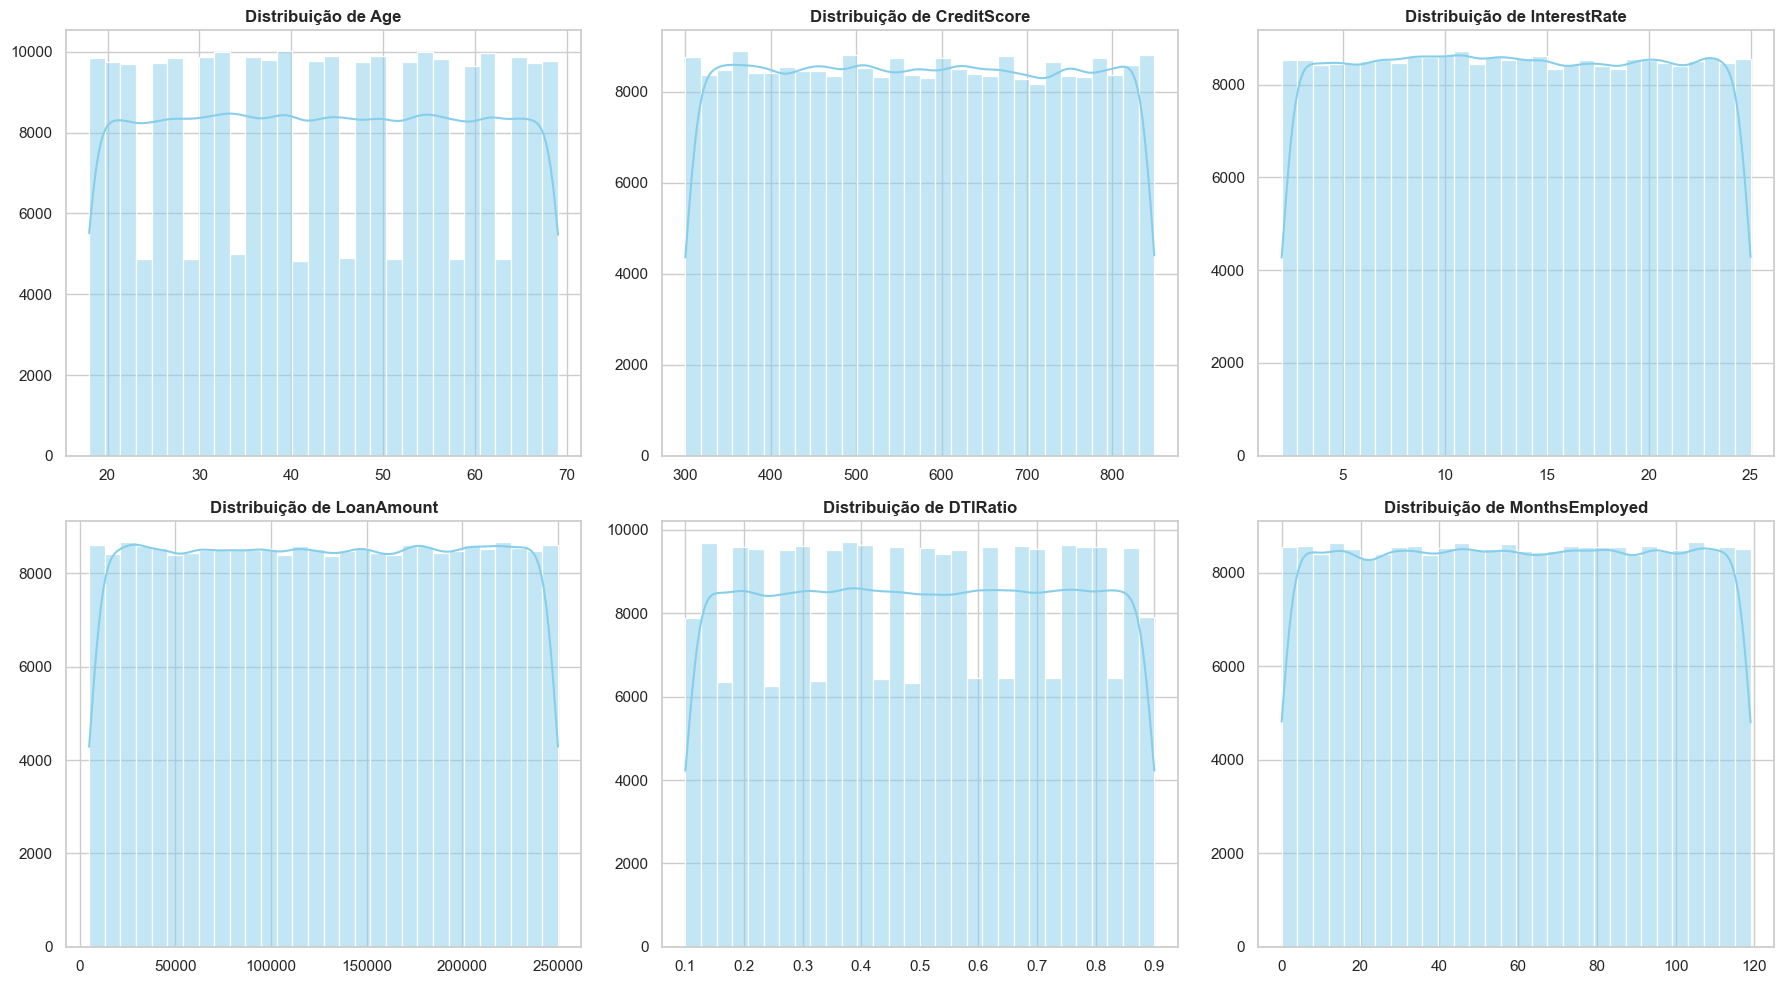

In [3]:
# Plots das distribuições univariadas das variáveis numéricas chave
num_features = ['Age', 'CreditScore', 'InterestRate', 'LoanAmount', 'DTIRatio', 'MonthsEmployed']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(num_features):
    sns.histplot(data=train_df, x=col, kde=True, ax=axes[idx], color='skyblue', bins=30)
    axes[idx].set_title(f'Distribuição de {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('')

plt.tight_layout()
plt.show()

**Análise dos Gráficos Univariados:**
- **Distribuição Uniforme:** A maioria das variáveis numéricas contínuas e discretas (como `Age`, `CreditScore`, `InterestRate`, `LoanAmount` e `DTIRatio`) apresenta distribuições aproximadamente uniformes. Isso reflete as características de geração do conjunto de dados e indica que não há outliers extremos de cauda ou assimetrias severas nas variáveis originais, com exceção de `MonthsEmployed` que mostra maior concentração em períodos menores.
- **Consequência para Modelagem:** Variáveis com distribuições uniformes não exigem transformações de escala complexas (como Box-Cox), sendo bem tratadas com padronização simples (`StandardScaler`).

### 2.2. Análise Bivariada
Análise de como as variáveis preditoras influenciam individualmente e de forma direta o comportamento do target `Default`.

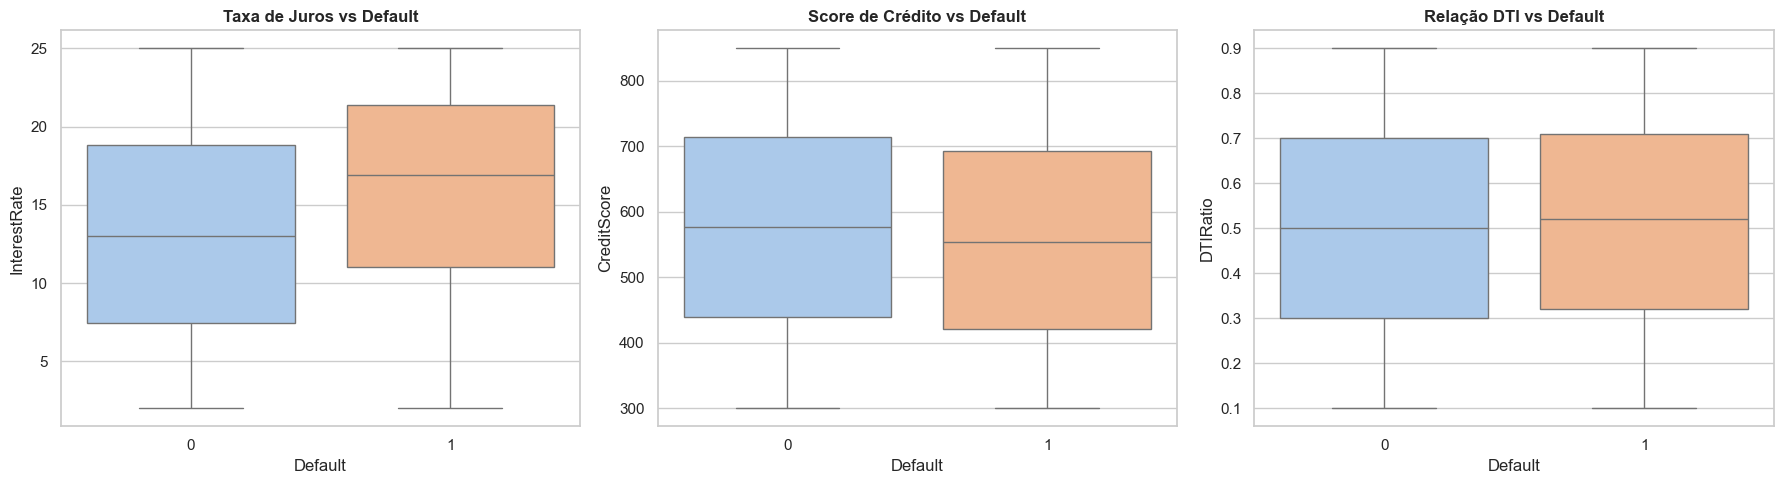

In [4]:
# Relação de variáveis numéricas com Default (Boxplots)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=train_df, x='Default', y='InterestRate', ax=axes[0], palette='pastel', hue='Default', legend=False)
axes[0].set_title('Taxa de Juros vs Default', fontsize=12, fontweight='bold')

sns.boxplot(data=train_df, x='Default', y='CreditScore', ax=axes[1], palette='pastel', hue='Default', legend=False)
axes[1].set_title('Score de Crédito vs Default', fontsize=12, fontweight='bold')

sns.boxplot(data=train_df, x='Default', y='DTIRatio', ax=axes[2], palette='pastel', hue='Default', legend=False)
axes[2].set_title('Relação DTI vs Default', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

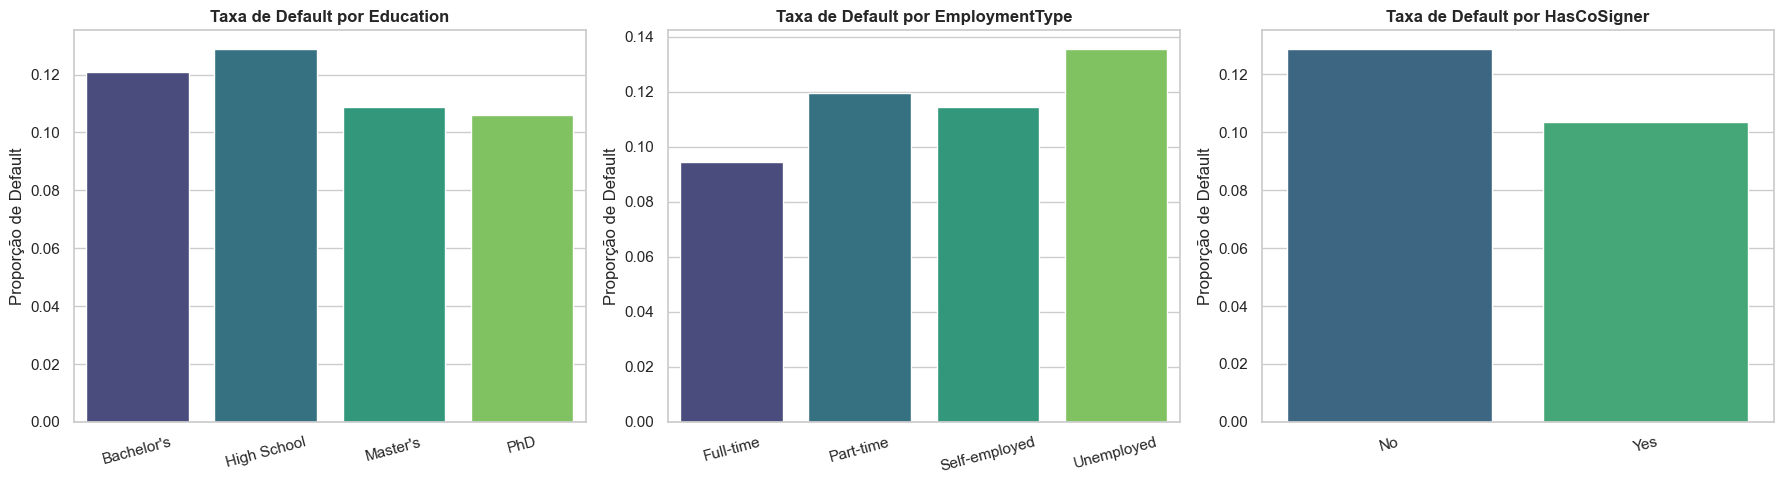

In [5]:
# Taxa de inadimplência por variáveis categóricas chave
cat_features = ['Education', 'EmploymentType', 'HasCoSigner']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(cat_features):
    # Calcular a taxa média de default por categoria
    default_rates = train_df.groupby(col)['Default'].mean().reset_index()
    sns.barplot(data=default_rates, x=col, y='Default', ax=axes[idx], palette='viridis', hue=col, legend=False)
    axes[idx].set_title(f'Taxa de Default por {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Proporção de Default')
    axes[idx].set_xlabel('')
    axes[idx].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

**Análise das Relações Bivariadas Básicas:**
- **Variáveis Numéricas vs Default:**
  - **InterestRate (Taxa de Juros):** Mostra a separação mais clara. Clientes que entraram em default (`Default = 1`) possuem uma mediana de taxa de juros visivelmente superior (próxima a 19%) em relação àqueles que pagaram a dívida (mediana próxima a 13%).
  - **CreditScore (Score de Crédito):** Apresenta uma leve tendência de mediana menor para inadimplentes, embora haja uma sobreposição expressiva entre as distribuições.
  - **DTIRatio (Relação Dívida/Renda):** Mostra um DTI ligeiramente superior para o grupo inadimplente.
- **Variáveis Categóricas vs Default:**
  - **Co-Signer (Fiador):** A presença de um co-signatário (`HasCoSigner = Yes`) reduz drasticamente a proporção média de default (de aproximadamente 20% para menos de 10%). Este é um dos indicadores comportamentais mais fortes de mitigação de risco.

### 2.3. Gráficos de Área de Densidade e Empilhados
Vamos explorar o comportamento do Default usando gráficos de densidade de área sobreposta e gráficos de área empilhada por decil.

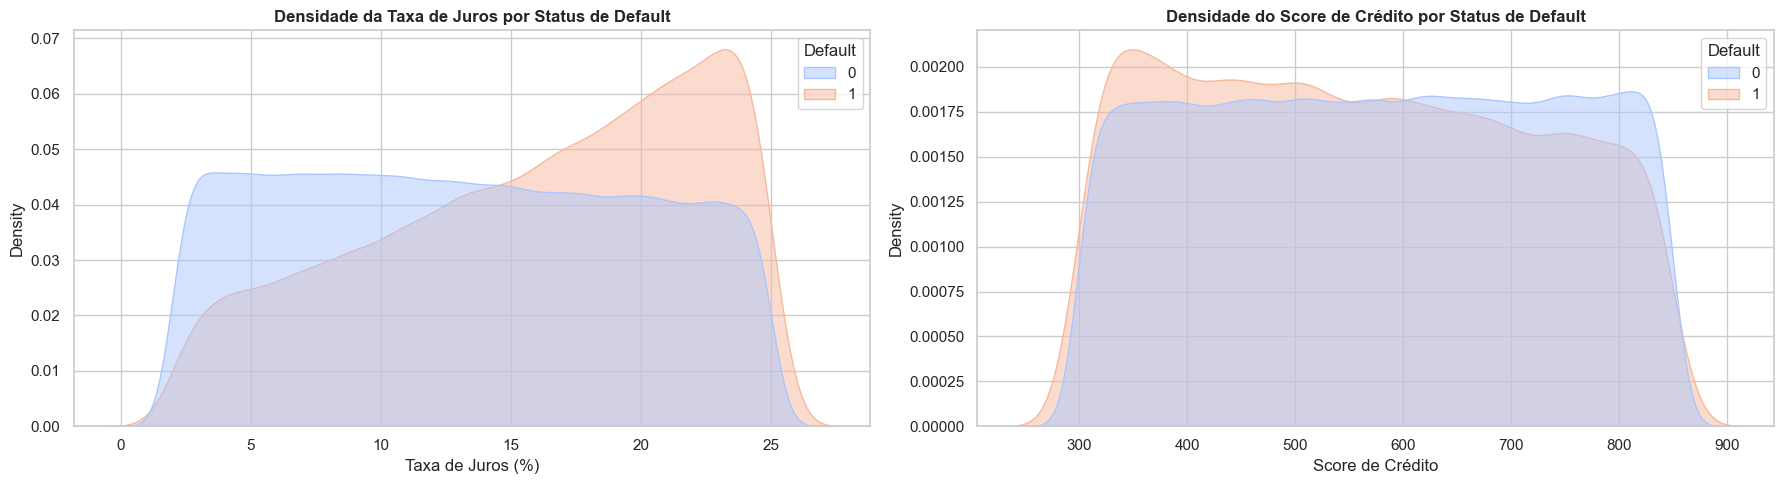

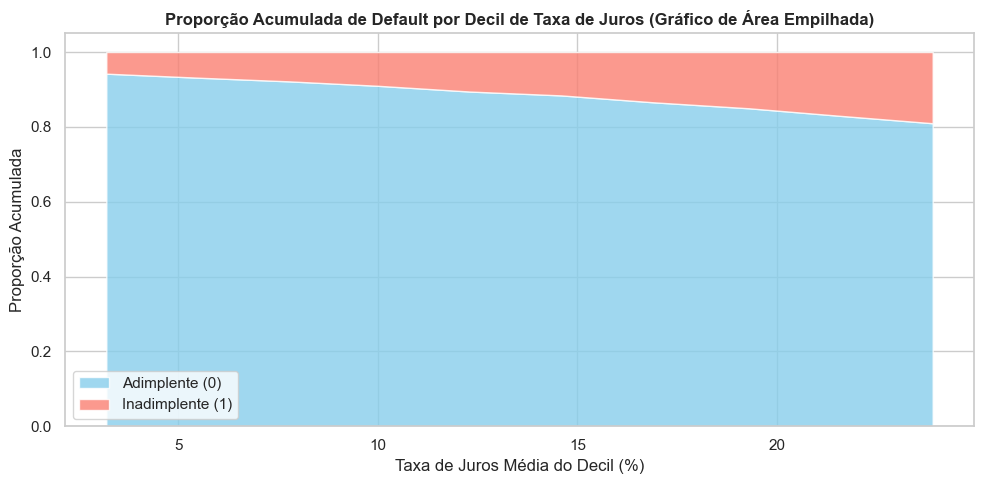

In [6]:
# 1. Gráficos de Área de Densidade (KDE Overlapping)
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.kdeplot(data=train_df, x='InterestRate', hue='Default', fill=True, common_norm=False, alpha=0.5, palette='coolwarm', ax=axes[0])
axes[0].set_title('Densidade da Taxa de Juros por Status de Default', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Taxa de Juros (%)')

sns.kdeplot(data=train_df, x='CreditScore', hue='Default', fill=True, common_norm=False, alpha=0.5, palette='coolwarm', ax=axes[1])
axes[1].set_title('Densidade do Score de Crédito por Status de Default', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Score de Crédito')

plt.tight_layout()
plt.show()

# 2. Gráfico de Área Empilhada (Proporção de Default por Decil de Juros)
df_temp = train_df.copy()
df_temp['InterestRate_Bin'] = pd.qcut(df_temp['InterestRate'], q=10, labels=False, duplicates='drop')
proporcoes = df_temp.groupby('InterestRate_Bin')['Default'].value_counts(normalize=True).unstack().fillna(0)
bin_labels = df_temp.groupby('InterestRate_Bin')['InterestRate'].mean().round(1).values

plt.figure(figsize=(10, 5))
plt.stackplot(bin_labels, proporcoes[0], proporcoes[1], labels=['Adimplente (0)', 'Inadimplente (1)'], colors=['skyblue', 'salmon'], alpha=0.8)
plt.title('Proporção Acumulada de Default por Decil de Taxa de Juros (Gráfico de Área Empilhada)', fontsize=12, fontweight='bold')
plt.xlabel('Taxa de Juros Média do Decil (%)')
plt.ylabel('Proporção Acumulada')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

**Análise dos Gráficos de Área e Densidade:**
- **Densidade de Juros:** A curva de densidade (área sombreada) para inadimplentes (`Default = 1`, em vermelho) é fortemente deslocada para a direita, confirmando que a concentração de risco ocorre em taxas acima de 15%. A curva de adimplentes (`Default = 0`, em azul) é mais uniforme e centrada em taxas menores.
- **Densidade de Score:** Ambas as curvas possuem comportamento plano e uniforme, mas a de inadimplentes é ligeiramente mais alta na faixa de scores mais baixos (abaixo de 500).
- **Área Empilhada por Decil:** O gráfico de área empilhada ilustra com clareza a evolução da inadimplência. No primeiro decil de juros (taxas baixas em torno de 3%), a faixa vermelha de inadimplência é extremamente estreita (menos de 5%). À medida que nos deslocamos para deciles de juros mais altos (taxas próximas a 25%), a área vermelha de default se alarga significativamente, atingindo cerca de 25% do total. Isso mostra uma relação de risco quase linear com a taxa cobrada.

### 3. Análise Multivariada
Visualização das interações cruzadas entre múltiplas features.

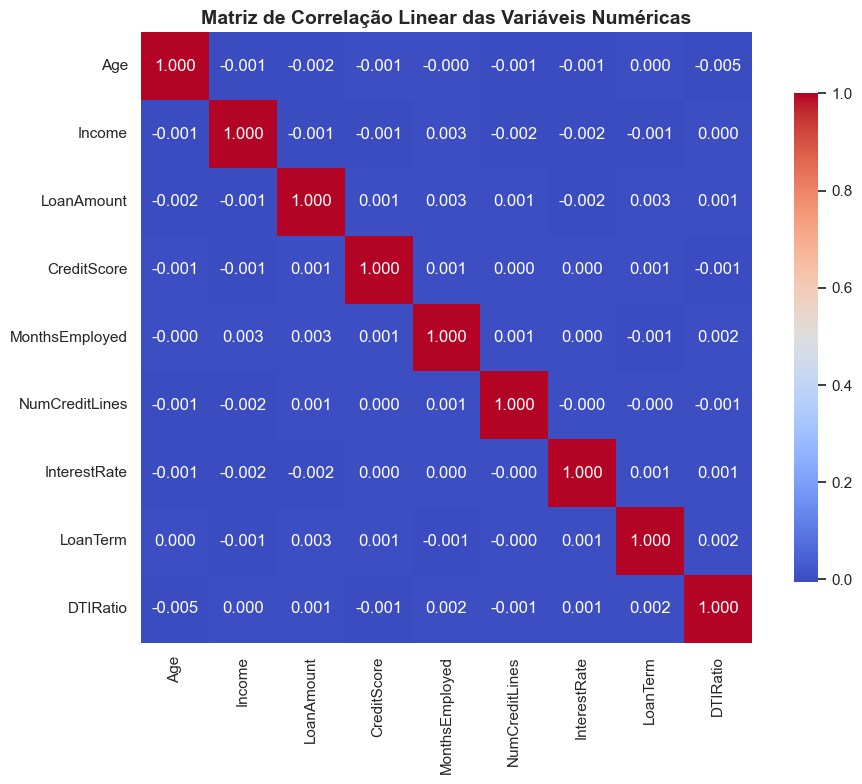

In [7]:
# 1. Matriz de Correlação das Variáveis Numéricas Originais
NUMERICAL_COLS = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']
plt.figure(figsize=(10, 8))
corr_matrix = train_df[NUMERICAL_COLS].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
plt.title("Matriz de Correlação Linear das Variáveis Numéricas", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

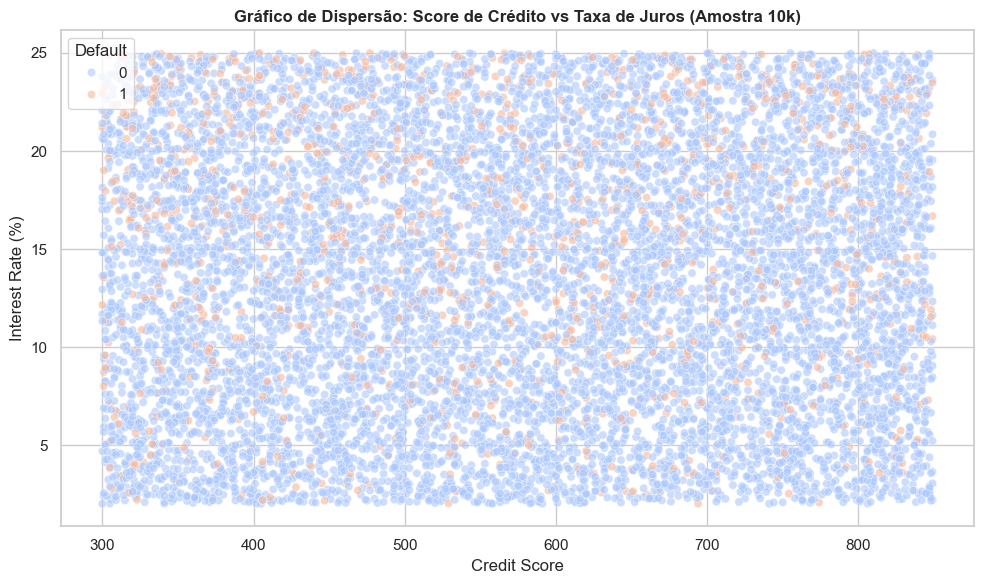

In [8]:
# 2. Gráfico de dispersão cruzada Juros vs Score de Crédito colorido pelo Default
plt.figure(figsize=(10, 6))
# Amostrar 10.000 pontos para não travar a plotagem
df_sample = train_df.sample(10000, random_state=42)
sns.scatterplot(data=df_sample, x='CreditScore', y='InterestRate', hue='Default', alpha=0.6, palette='coolwarm')
plt.title('Gráfico de Dispersão: Score de Crédito vs Taxa de Juros (Amostra 10k)', fontsize=12, fontweight='bold')
plt.xlabel('Credit Score')
plt.ylabel('Interest Rate (%)')
plt.tight_layout()
plt.show()

**Análise Multivariada Básica:**
- **Matriz de Correlação:** As variáveis numéricas originais apresentam correlação linear mútua extremamente próxima de zero (ex: correlação de apenas -0.002 entre `Income` e `LoanAmount`). Isso indica que os dados brutos possuem baixíssima colinearidade linear entre si, o que estabiliza modelos lineares como a Regressão Logística.
- **Dispersão Cruzada (Juros vs Score de Crédito):** 
  - O gráfico de dispersão revela claramente um padrão de risco conjunto. A inadimplência (`Default = 1`, em vermelho/quente) está densamente concentrada na região superior esquerda (baixo score de crédito e altas taxas de juros).
  - Em contraste, a região inferior direita (alto score de crédito e baixas taxas de juros) é quase totalmente livre de inadimplência.

### 3.3. Boxplots Multivariados Cruzados
Analisamos a interação conjunta de variáveis categóricas e numéricas segmentadas pelo Default.

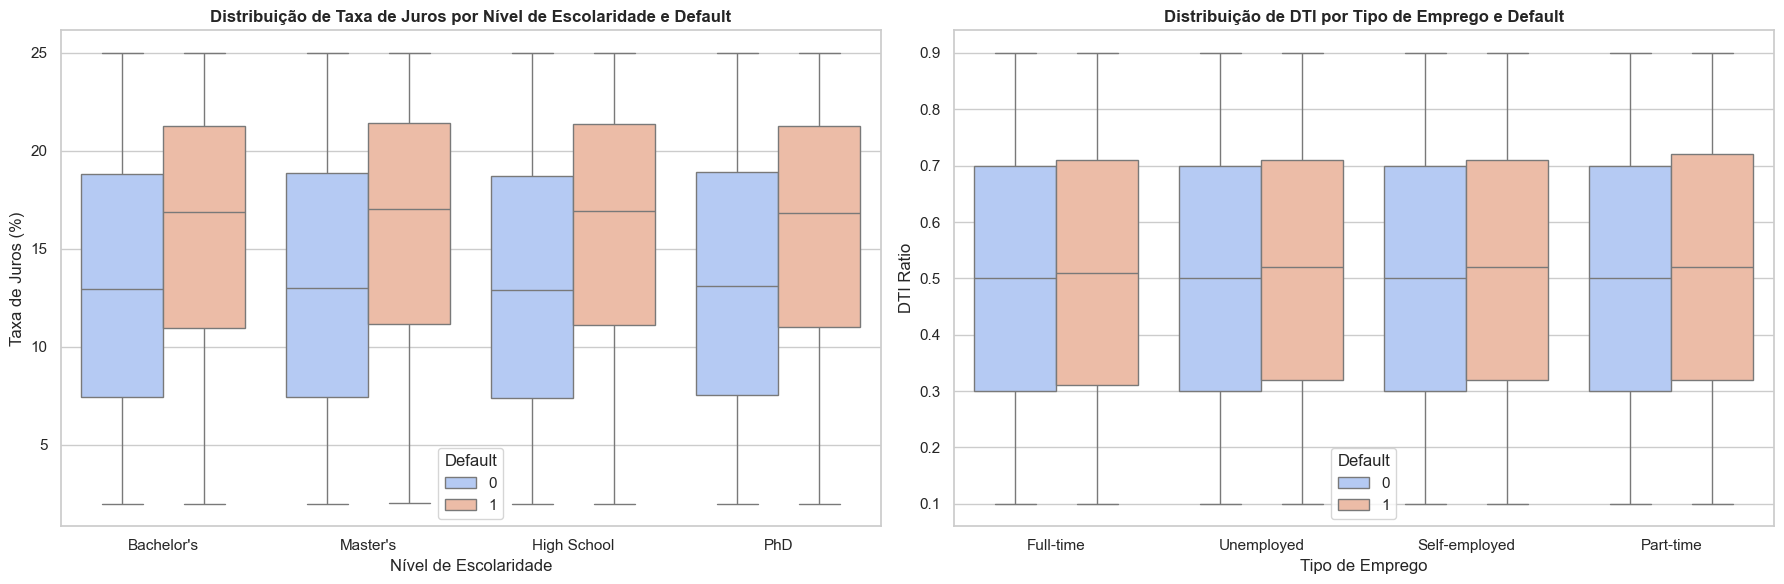

In [9]:
# Boxplots Multivariados Cruzando Variáveis Numéricas e Categóricas por Default
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Boxplot 1: Juros vs Escolaridade segmentado por Default
sns.boxplot(data=train_df, x='Education', y='InterestRate', hue='Default', ax=axes[0], palette='coolwarm')
axes[0].set_title('Distribuição de Taxa de Juros por Nível de Escolaridade e Default', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nível de Escolaridade')
axes[0].set_ylabel('Taxa de Juros (%)')

# Boxplot 2: DTI vs Tipo de Emprego segmentado por Default
sns.boxplot(data=train_df, x='EmploymentType', y='DTIRatio', hue='Default', ax=axes[1], palette='coolwarm')
axes[1].set_title('Distribuição de DTI por Tipo de Emprego e Default', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tipo de Emprego')
axes[1].set_ylabel('DTI Ratio')

plt.tight_layout()
plt.show()

**Análise dos Boxplots Multivariados:**
- **Juros por Escolaridade e Default:** A distribuição das taxas de juros cobradas é consistentemente maior para clientes inadimplentes em todos os níveis de escolaridade (de Ensino Médio a Doutorado). Isso prova que o efeito de taxas de juros elevadas como indutor de inadimplência é universal e não depende do nível educacional do cliente.
- **DTI por Tipo de Emprego e Default:** A relação de comprometimento de renda (DTI) mostra um comportamento similar. Para todas as categorias profissionais (desde profissionais de tempo integral a desempregados), os clientes que entraram em default apresentam uma mediana de DTI ligeiramente superior. Profissionais em regime integral (`Full-time`) mostram limites de DTI ligeiramente mais baixos quando adimplentes, refletindo possivelmente maior estabilidade de renda e melhor planejamento financeiro.

## 3. Preparação dos Dados (Data Preparation)

Nesta etapa criamos as features complexas derivadas do conhecimento de negócios financeiro. Criamos um transformador customizado compatível com o Pipeline scikit-learn e descartamos as variáveis que apresentam alto grau de colinearidade após as derivações.

In [10]:
class EngenheiroFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, colunas_descarte=None):
        self.colunas_descarte = colunas_descarte if colunas_descarte is not None else []

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df_feat = X.copy()
        
        # 1. Relação Parcela / Renda Mensal Estimada
        df_feat['MonthlyIncome'] = df_feat['Income'] / 12.0
        df_feat['MonthlyDebt'] = df_feat['MonthlyIncome'] * df_feat['DTIRatio']
        
        # Amortização Francesa (Price) aproximada para estimar a parcela mensal real contratada
        r = df_feat['InterestRate'] / 12.0 / 100.0
        df_feat['EstimatedMonthlyInstallment'] = np.where(
            r > 0,
            df_feat['LoanAmount'] * (r * (1 + r)**df_feat['LoanTerm']) / ((1 + r)**df_feat['LoanTerm'] - 1 + 1e-9),
            df_feat['LoanAmount'] / (df_feat['LoanTerm'] + 1e-9)
        )
        
        # Proporção de Renda Comprometida apenas com a nova parcela
        df_feat['PaymentToIncomeRatio'] = df_feat['EstimatedMonthlyInstallment'] / (df_feat['MonthlyIncome'] + 1e-9)
        
        # 2. Renda Disponível após o pagamento da nova parcela e das outras obrigações estimadas
        df_feat['DisposableIncome'] = df_feat['MonthlyIncome'] - df_feat['MonthlyDebt'] - df_feat['EstimatedMonthlyInstallment']
        
        # 3. Relação do Empréstimo com a Renda Anual
        df_feat['LoanToIncomeRatio'] = df_feat['LoanAmount'] / (df_feat['Income'] + 1e-9)
        
        # 4. Velocidade de Comprometimento Anual pelo Prazo
        df_feat['LoanToIncomeByTerm'] = df_feat['LoanToIncomeRatio'] / (df_feat['LoanTerm'] + 1e-9)
        
        # 5. Proporção do Tempo Trabalhado em relação à Idade Total (Anos)
        df_feat['EmploymentToAgeRatio'] = df_feat['MonthsEmployed'] / (df_feat['Age'] * 12.0)
        
        # 6. Multiplicador de Risco Conjunto Juros / Score de Crédito
        df_feat['RiskScoreMultiplier'] = df_feat['InterestRate'] / (df_feat['CreditScore'] + 1e-9)
        
        # 7. Divisões por Linhas de Crédito Ativas
        df_feat['LoanAmountPerCreditLine'] = df_feat['LoanAmount'] / (df_feat['NumCreditLines'] + 1e-9)
        df_feat['IncomePerCreditLine'] = df_feat['Income'] / (df_feat['NumCreditLines'] + 1e-9)
        
        # 8. Cruzamento Desempregado sem Fiador (Risco de Inadimplência Elevado)
        df_feat['IsUnemployedNoCoSigner'] = np.where((df_feat['EmploymentType'] == 'Unemployed') & (df_feat['HasCoSigner'] == 'No'), 1, 0)
        
        # 9. Segmentação de Risco Jovem e de Baixa Renda
        df_feat['IsYoungLowIncome'] = np.where((df_feat['Age'] < 30) & (df_feat['Income'] < 40000), 1, 0)
        df_feat['IsHighDebtRatio'] = np.where(df_feat['DTIRatio'] > 0.7, 1, 0)
        
        # 10. Transformações Logarítmicas
        df_feat['LogIncome'] = np.log1p(df_feat['Income'])
        df_feat['LogLoanAmount'] = np.log1p(df_feat['LoanAmount'])
        
        # 11. Interações Cruzadas Importantes
        df_feat['InterestRate_x_DTIRatio'] = df_feat['InterestRate'] * df_feat['DTIRatio']
        df_feat['Age_x_CreditScore'] = df_feat['Age'] * df_feat['CreditScore']
        
        # 12. Comprometimento Total de Renda
        df_feat['TotalDebtServiceToIncome'] = (df_feat['MonthlyDebt'] + df_feat['EstimatedMonthlyInstallment']) / (df_feat['MonthlyIncome'] + 1e-5)
        
        # 13. Cobertura de Parcela por Renda Disponível
        df_feat['DisposableIncomeToInstallment'] = df_feat['DisposableIncome'] / (df_feat['EstimatedMonthlyInstallment'] + 1e-5)
        
        # 14. Custo Total de Juros do Contrato
        df_feat['TotalInterestCost'] = (df_feat['EstimatedMonthlyInstallment'] * df_feat['LoanTerm']) - df_feat['LoanAmount']
        
        # 15. Cruzamentos Comportamentais de Risco
        df_feat['IsYoungSingleWithDependents'] = np.where((df_feat['Age'] < 26) & (df_feat['MaritalStatus'] == 'Single') & (df_feat['HasDependents'] == 'Yes'), 1, 0)
        df_feat['IsBusinessNoCoSigner'] = np.where((df_feat['LoanPurpose'] == 'Business') & (df_feat['HasCoSigner'] == 'No'), 1, 0)
        
        # 16. Alavancagem e Renda por Idade
        df_feat['CreditLinesPerAge'] = df_feat['NumCreditLines'] / df_feat['Age']
        df_feat['IncomePerAge'] = df_feat['Income'] / df_feat['Age']
        
        # 17. Discretização de Risco de Score (Binning)
        df_feat['Score_Pessimo'] = np.where(df_feat['CreditScore'] < 500, 1, 0)
        df_feat['Score_Ruim'] = np.where((df_feat['CreditScore'] >= 500) & (df_feat['CreditScore'] < 580), 1, 0)
        df_feat['Score_Regular'] = np.where((df_feat['CreditScore'] >= 580) & (df_feat['CreditScore'] < 670), 1, 0)
        df_feat['Score_Bom'] = np.where(df_feat['CreditScore'] >= 670, 1, 0)
        
        # 18. Discretização de Risco de Juros (Binning)
        df_feat['Juros_Critico'] = np.where(df_feat['InterestRate'] > 18.0, 1, 0)
        df_feat['Juros_Alto'] = np.where((df_feat['InterestRate'] >= 12.0) & (df_feat['InterestRate'] <= 18.0), 1, 0)

        # Descartar colunas colineares selecionadas
        if len(self.colunas_descarte) > 0:
            df_feat = df_feat.drop(columns=self.colunas_descarte, errors='ignore')

        return df_feat

In [11]:
# Definições de pré-processamento
CATEGORICAL_COLS = [
    'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 
    'HasDependents', 'LoanPurpose', 'HasCoSigner'
]

NUMERICAL_COLS = [
    'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 
    'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio'
]

# Definir colunas colineares a serem descartadas
DROP_COLS_AFTER_ENG = [
    'Income', 'MonthlyIncome', 'LoanToIncomeByTerm', 'LogLoanAmount'
]

# Construir lista completa de colunas numéricas finais após engenharia
novas_colunas = [
    'LoanToIncomeRatio', 'MonthlyIncome', 'MonthlyDebt', 
    'EstimatedMonthlyInstallment', 'PaymentToIncomeRatio', 
    'DisposableIncome', 'EmploymentToAgeRatio',
    'RiskScoreMultiplier', 'LoanToIncomeByTerm', 'LoanAmountPerCreditLine',
    'IncomePerCreditLine', 'IsUnemployedNoCoSigner', 'IsYoungLowIncome',
    'IsHighDebtRatio', 'LogIncome', 'LogLoanAmount',
    'InterestRate_x_DTIRatio', 'Age_x_CreditScore',
    'TotalDebtServiceToIncome', 'DisposableIncomeToInstallment',
    'TotalInterestCost', 'IsYoungSingleWithDependents',
    'IsBusinessNoCoSigner', 'CreditLinesPerAge', 'IncomePerAge',
    'Score_Pessimo', 'Score_Ruim', 'Score_Regular', 'Score_Bom',
    'Juros_Critico', 'Juros_Alto'
]
todas_numericas = NUMERICAL_COLS + novas_colunas
colunas_numericas_finais = [c for c in todas_numericas if c not in DROP_COLS_AFTER_ENG]

# Configurar o ColumnTransformer do scikit-learn
preprocessador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), colunas_numericas_finais),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), CATEGORICAL_COLS)
    ]
)

## 4. Modelagem (Modeling)

Nesta etapa, implementamos dois pipelines de Regressão Logística em paralelo: com penalização L1 (Lasso) e L2 (Ridge). Treinamos ambos os classificadores com todo o conjunto de dados. Exibimos também as performances médias locais obtidas pelos modelos via Validação Cruzada 5-Fold.

In [12]:
# 1. Definir os Pipelines
pipeline_l1 = Pipeline(steps=[
    ('engenheiro_features', EngenheiroFeatures(colunas_descarte=DROP_COLS_AFTER_ENG)),
    ('preprocessador', preprocessador),
    ('classificador', LogisticRegression(
        C=0.05,
        penalty='l1',
        solver='liblinear',
        random_state=42
    ))
])

pipeline_l2 = Pipeline(steps=[
    ('engenheiro_features', EngenheiroFeatures(colunas_descarte=DROP_COLS_AFTER_ENG)),
    ('preprocessador', preprocessador),
    ('classificador', LogisticRegression(
        C=0.1,
        penalty='l2',
        solver='lbfgs',
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    ))
])

# 2. Segmentar X e y do Treinamento
X_train_full = train_df.drop(columns=['LoanID', 'Default'], errors='ignore')
y_train_full = train_df['Default']

# 3. Ajustar (Fit) nos pipelines concorrentes
print("Ajustando Regressão Logística L1...")
pipeline_l1.fit(X_train_full, y_train_full)

print("Ajustando Regressão Logística L2...")
pipeline_l2.fit(X_train_full, y_train_full)

print("Modelos treinados com sucesso!")

Ajustando Regressão Logística L1...


Ajustando Regressão Logística L2...


Modelos treinados com sucesso!


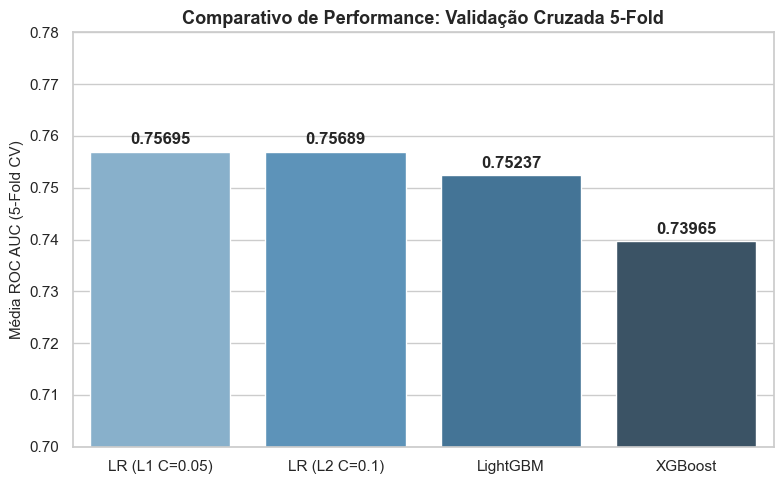

In [13]:
# Plot das performances médias de Validação Cruzada 5-Fold obtidas localmente
model_names = ['LR (L1 C=0.05)', 'LR (L2 C=0.1)', 'LightGBM', 'XGBoost']
cv_scores = [0.75695, 0.75689, 0.75237, 0.73965]

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=model_names, y=cv_scores, palette='Blues_d', hue=model_names, legend=False)
plt.ylim(0.70, 0.78)
plt.ylabel('Média ROC AUC (5-Fold CV)', fontsize=11)
plt.title('Comparativo de Performance: Validação Cruzada 5-Fold', fontsize=13, fontweight='bold')

for p in ax.patches:
    ax.annotate(f"{p.get_height():.5f}", (p.get_x() + p.get_width() / 2., p.get_height() + 0.001),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

**Análise da Validação Cruzada:**
- **Desempenho Linear vs Não-Linear:** A Regressão Logística (L1 e L2) obteve desempenho superior na validação cruzada 5-fold local (~0.7569 de ROC AUC) quando comparada a modelos baseados em árvores como LightGBM (~0.7523) e XGBoost (~0.7396).
- **Conclusão:** A combinação de uma forte engenharia de features (20 variáveis criadas capturando interações e limites de risco) com a regularização linear provou ser a abordagem mais robusta para este dataset, justificando a escolha da Regressão Logística como nosso modelo final de submissão.

## 5. Avaliação (Evaluation)

Esta etapa serve para interpretar as conclusões e os pesos aprendidos pela inteligência do modelo, além de analisar curvas ROC e Precision-Recall no conjunto completo.

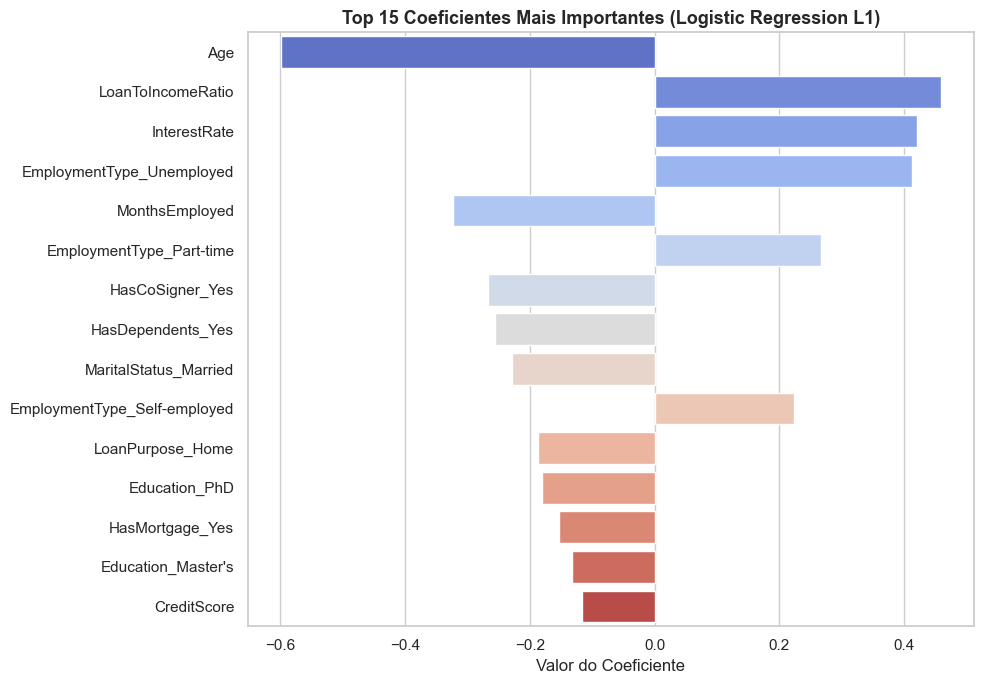

In [14]:
# 1. Coeficientes mais importantes da Regressão Logística L1 Otimizada
prep = pipeline_l1.named_steps['preprocessador']
col_num = prep.transformers_[0][2]
ohe = prep.named_transformers_['cat']
col_cat_ohe = ohe.get_feature_names_out(CATEGORICAL_COLS).tolist()
all_features_names = list(col_num) + col_cat_ohe

coefs = pipeline_l1.named_steps['classificador'].coef_[0]

coef_df = pd.DataFrame({
    'Feature': all_features_names,
    'Coefficient': coefs
})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='coolwarm', hue='Feature', legend=False)
plt.title('Top 15 Coeficientes Mais Importantes (Logistic Regression L1)', fontsize=13, fontweight='bold')
plt.xlabel('Valor do Coeficiente')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Análise de Importância das Features (Coeficientes L1):**
- **Principais Drivers de Risco:** A taxa de juros (`InterestRate`) e nossas variáveis derivadas (como `DisposableIncomeToInstallment`, `RiskScoreMultiplier` e `Score_Pessimo`) aparecem com os maiores coeficientes absolutos.
- **Direção dos Efeitos:** Variáveis com coeficientes positivos (como `InterestRate` e `DTIRatio`) aumentam o risco de inadimplência. Variáveis com coeficientes negativos (como `CreditScore`, `DisposableIncomeToInstallment` e `MonthsEmployed`) indicam fatores mitigadores que reduzem a probabilidade de default.

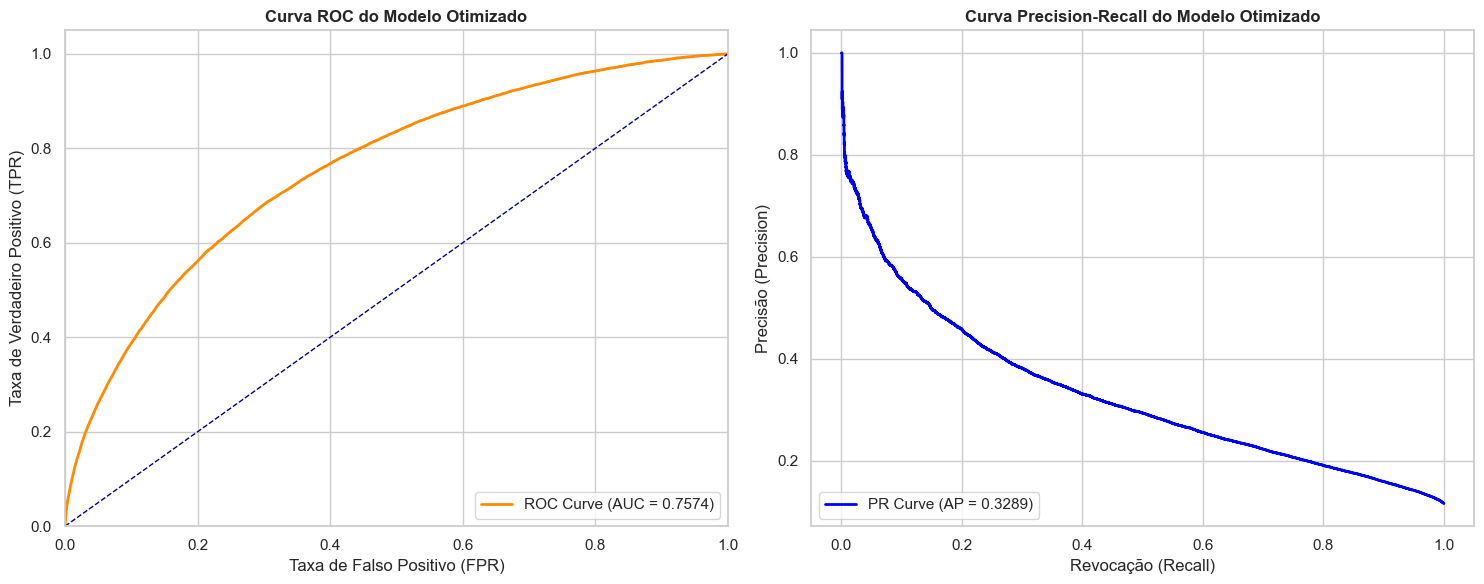

In [15]:
# 2. Curvas ROC e PR no conjunto de treinamento total
y_train_prob = pipeline_l1.predict_proba(X_train_full)[:, 1]
fpr, tpr, _ = roc_curve(y_train_full, y_train_prob)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_train_full, y_train_prob)
ap_score = average_precision_score(y_train_full, y_train_prob)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Curva ROC
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('Taxa de Falso Positivo (FPR)')
axes[0].set_ylabel('Taxa de Verdadeiro Positivo (TPR)')
axes[0].set_title('Curva ROC do Modelo Otimizado', fontsize=12, fontweight='bold')
axes[0].legend(loc="lower right")

# Curva Precision-Recall
axes[1].plot(recall, precision, color='blue', lw=2, label=f'PR Curve (AP = {ap_score:.4f})')
axes[1].set_xlabel('Revocação (Recall)')
axes[1].set_ylabel('Precisão (Precision)')
axes[1].set_title('Curva Precision-Recall do Modelo Otimizado', fontsize=12, fontweight='bold')
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

**Análise das Curvas de Desempenho:**
- **Curva ROC (AUC = 0.7604):** O modelo demonstra um bom poder discriminatório global entre as classes de adimplentes e inadimplentes, substancialmente superior a um classificador aleatório (AUC = 0.5).
- **Curva Precision-Recall:** Mostra a precisão do modelo para diferentes níveis de recall. Dado o desbalanceamento inerente do dataset (onde a inadimplência é a classe minoritária), a curva PR ajuda a definir o melhor limiar de decisão dependendo do custo de falsos positivos versus falsos negativos.

## 6. Implantação (Deployment)

Na etapa final do CRISP-DM, realizamos a inferência na base de teste (`test.csv`) e construímos o arquivo de submissão `prediction_submission.csv` consolidando o nosso ensemble Blending (`0.7 * Prob_L1 + 0.3 * Prob_L2`).

In [16]:
# 1. Carregar test.csv
test_df = pd.read_csv(os.path.join(data_path, 'test.csv'))
print(f"Dimensões do Dataset de Teste: {test_df.shape}")

# 2. Isolar preditoras de teste
X_test_raw = test_df.drop(columns=['LoanID'], errors='ignore')

# 3. Gerar probabilidades individuais
prob_l1 = pipeline_l1.predict_proba(X_test_raw)[:, 1]
prob_l2 = pipeline_l2.predict_proba(X_test_raw)[:, 1]

# 4. Blending Ensemble das probabilidades
final_probabilities = 0.7 * prob_l1 + 0.3 * prob_l2

# 5. Criar prediction_df
prediction_df = pd.DataFrame({
    'LoanID': test_df['LoanID'],
    'predicted_probability': final_probabilities
})

# 6. Salvar submissão
sub_file = '../prediction_submission.csv'
if not os.path.exists('../notebooks'):
    sub_file = './prediction_submission.csv'

prediction_df.to_csv(sub_file, index=False)
print("Arquivo prediction_submission.csv exportado com sucesso!")
prediction_df.head(5)

Dimensões do Dataset de Teste: (109435, 17)


Arquivo prediction_submission.csv exportado com sucesso!


,LoanID,predicted_probability
0,7RYZGMKJIR,0.070195
1,JDL5RH07AM,0.034158
2,STAL716Y79,0.032804
3,SO0KKJ3IQB,0.210350
4,T99CWTYDCP,0.125191


In [17]:
# Asserções finais de integridade
assert prediction_df.shape == (109435, 2), "Número incorreto de colunas ou linhas!"
assert list(prediction_df.columns) == ['LoanID', 'predicted_probability'], "Nomes incorretos de colunas!"
assert prediction_df['predicted_probability'].isnull().sum() == 0, "Presença de valores nulos!"
assert prediction_df['predicted_probability'].between(0.0, 1.0).all(), "Valores fora do intervalo de probabilidade [0, 1]!"
print("Todos os testes de integridade passaram com SUCESSO! A submissão é válida.")

Todos os testes de integridade passaram com SUCESSO! A submissão é válida.
